In [1]:
import integrator as itg
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kernels

In [2]:
def f_1(x):
    return x

In [ ]:
num_traj = 10
x0 = np.random.uniform(0,1,(num_traj,1))
tstar = np.linspace(0, 1, 101)
t = [tstar for _ in range(num_traj)]
traj = itg.rk4_solver(f_1, x0, t, step_size=0.01)


In [4]:
gamma2 = 0.01
traj_noisy = [traj[k] + np.random.normal(0, np.sqrt(gamma2), traj[k].shape) for k in range(num_traj)]

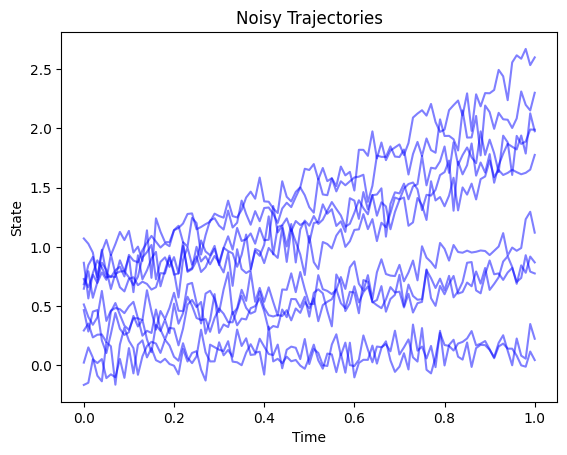

In [5]:
for k in range(num_traj):
    plt.plot(tstar, traj_noisy[k], color='blue', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('State')
plt.title('Noisy Trajectories')
plt.savefig('pictures/noisy_trajectories.pdf')

In [6]:
from importlib import reload
kernels = reload(kernels)
traj_concat = np.concatenate(traj_noisy, axis=0)
bw = np.std(traj_concat) # * (4 / (3 * traj_concat.shape[0]))**0.2
# bw = 1.0
print(f"Bandwidth: {bw}")
bw_t = np.std(tstar) # * (4 / (3 * traj_concat.shape[0]))**0.2
print(f"Bandwidth (time): {bw_t}")
kernel = lambda x, y: kernels.gaussian_kernel(x, y, bw=bw)
x_kernel = lambda s, t: kernels.gaussian_kernel(s, t, bw=bw_t)

Bandwidth: 0.6036742329597473
Bandwidth (time): 0.29154759474226505


In [7]:
def get_gram_matrix(t, traj_latent, kernel):
    N = traj_latent[0].shape[0]
    traj_concat = np.concatenate(traj_latent, axis=0)
    K = np.array(kernel(traj_concat, traj_concat))
    num_traj = len(traj_latent)
    idx = np.arange(N,K.shape[0], step=N)
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    K = np.delete(K, idx, axis=0)
    K = np.delete(K, idx, axis=1)
    delta_t = t[0][1:] - t[0][:-1]
    Delta_t = np.tile(delta_t, (num_traj,))
    K = K*Delta_t[:, None]/2.0*Delta_t[None, :]/2.0
    # K = np.cumsum(K, axis=0)
    # K = np.cumsum(K, axis=1)
    # K = K[1:, 1:]
    for i in range(num_traj):
        for j in range(num_traj):
            K[i*(N-1):(i+1)*(N-1), j*(N-1):(j+1)*(N-1)] = np.cumsum(np.cumsum(K[i*(N-1):(i+1)*(N-1), j*(N-1):(j+1)*(N-1)], axis=0), axis=1)
    return K

In [8]:
def get_occ_kerns(x, t, traj_latent, kernel):
    N = traj_latent[0].shape[0]
    traj_concat = np.concatenate(traj_latent, axis=0)
    K = np.array(kernel(x, traj_concat))
    num_traj = len(traj_latent)
    K = K[:,1:] + K[:,:-1]
    idx = np.arange(N,K.shape[1], step=N)
    K = np.delete(K, idx, axis=1)
    #K[:, idx] = 0
    delta_t = t[0][1:] - t[0][:-1]
    Delta_t = np.tile(delta_t, (num_traj,))
    K = K * Delta_t[None, :]/2.0
    # K = np.cumsum(K, axis=1)
    #K = K[:, 1:]
    # K[:, idx] = 0.0
    for i in range(num_traj):
        K[:, i*(N-1):(i+1)*(N-1)] = np.cumsum(K[:, i*(N-1):(i+1)*(N-1)], axis=1)
    return K

In [9]:
def get_xx_covar(t, x_kernel, x0_var):
    N = t.shape[0]
    K = x_kernel(t[:, None], t[:, None])
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    delta_t = t[1:] - t[:-1]
    K = K*delta_t[:, None]/2.0*delta_t[None, :]/2.0
    K = np.cumsum(K, axis=0)
    K = np.cumsum(K, axis=1)
    K = np.insert(K, 0, 0.0, axis=0)
    K = np.insert(K, 0, 0.0, axis=1)
    x0_var_mat = np.ones(K.shape)*x0_var
    return K + x0_var_mat

In [10]:
def get_z_zprime_covar(t, x_kernel, x0_var):
    N = t.shape[0]
    K = x_kernel(t[:, None], t[:, None])
    K = K[1:] + K[:-1]
    
    delta_t = t[1:] - t[:-1]
    K = K*delta_t[:, None]/2.0
    K = np.cumsum(K, axis=0)
    # K = np.cumsum(K, axis=1)
    K = np.insert(K, 0, 0.0, axis=0)
    # K = np.insert(K, 0, 0.0, axis=1)
    # x0_var_mat = np.ones(K.shape)*x0_var
    return K # + x0_var_mat

In [11]:
def sample_z_zprime(idx, t, traj_noisy, x_kernel, gamma2, x0_mean, x0_var, num_samples=1, eps=1e-6):
    t_idx = t[idx]
    K_xx = get_xx_covar(t_idx, x_kernel, x0_var)
    K_yy = x_kernel(t_idx[:, None], t_idx[:, None])
    K_xy = get_z_zprime_covar(t_idx, x_kernel, x0_var)
    big_matrix_2 = np.block([[K_xx], [K_xy.T]])
    prior_covar = np.block([[K_xx, K_xy], [K_xy.T, K_yy]])
    y_obs = traj_noisy[idx]
    y_doubled = np.concatenate([y_obs, y_obs], axis=0)
    mean = np.concatenate([np.repeat(x0_mean, len(t_idx)), np.zeros(len(t_idx))], axis=0)
    # print(mean.shape)
    covar = K_xx + gamma2 * np.eye(K_xx.shape[0])
    # print(f"Covariance matrix shape: {covar.shape}")
    mu_post = mean + big_matrix_2 @ np.linalg.solve(covar, y_obs[:, 0] - np.repeat(x0_mean, len(t_idx)))
    post_covar = prior_covar - big_matrix_2 @ np.linalg.solve(covar, big_matrix_2.T)
    # print(f"Posterior mean shape: {mu_post.shape}, Posterior covariance shape: {post_covar.shape}")
    samples = np.random.multivariate_normal(mu_post.flatten(), post_covar + eps * np.eye(post_covar.shape[0]), size=num_samples)
    # print(f"Sample shape: {samples.shape}")
    return samples

In [12]:
def sample_z_zprime_all(t, traj_noisy, x_kernel, gamma2, x0_var, num_samples=1, eps=1e-6):
    samples_list = []
    for idx in range(len(t)):
        rng = np.random.random_integers(0, 5000, num_samples)
        np.random.seed(rng) 
        x0_mean = traj_noisy[idx][0]  # Assuming the initial mean is the first observation of the trajectory
        samples = sample_z_zprime(idx, t, traj_noisy, x_kernel, gamma2, x0_mean, x0_var, num_samples=num_samples, eps=eps)
        samples_list.append(samples)
    sample_z_list = [samples[:, :len(t[0])] for samples in samples_list]
    sample_zprime_list = [samples[:, len(t[0]):] for samples in samples_list]
    shapes = [s.shape for s in sample_z_list]
    # print(f"Sample z shapes: {shapes}")
    # For reproducibility
    sample_z_list = [[sample_z_list[k][n] for k in range(len(samples_list))] for n in range(num_samples)]
    sample_zprime_list = [[sample_zprime_list[k][n] for k in range(len(samples_list))] for n in range(num_samples)]
    samples_list = [(sample_z_list[n], sample_zprime_list[n]) for n in range(num_samples)]
    return samples_list

In [13]:
traj_latent = sample_z_zprime_all(t, traj_noisy, x_kernel, gamma2, x0_var=0.1, num_samples=100, eps=1e-6)

/tmp/ipykernel_86931/2313747086.py:4: DeprecationWarning: This function is deprecated. Please call randint(0, 5000 + 1) instead
  rng = np.random.random_integers(0, 5000, num_samples)
/tmp/ipykernel_86931/523203492.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mu_post.flatten(), post_covar + eps * np.eye(post_covar.shape[0]), size=num_samples)


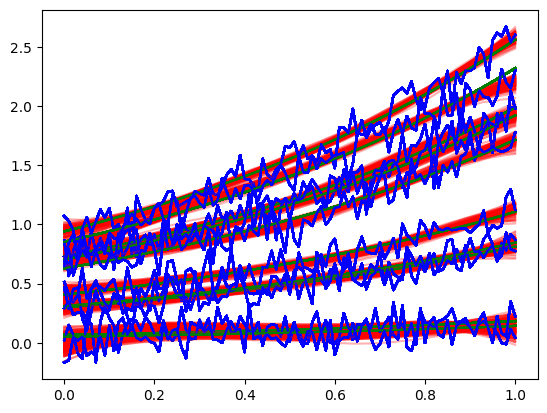

In [14]:
#traj_latent = sample_traj_latent(6, t, traj_noisy, x_kernel, gamma2, x0_mean=traj_noisy[6][0], x0_var=0.1, num_samples=100)
for l in range(100):
    for k in range(len(traj_latent[0][0])):
        plt.plot(t[k], traj_latent[l][0][k], color='red', label='Inferred Latent Trajectory', alpha=0.3)
        plt.plot(t[k], traj[k], color='green', label='True Trajectory')
        plt.plot(t[k], traj_noisy[k], color='blue', label='Noisy Observations')

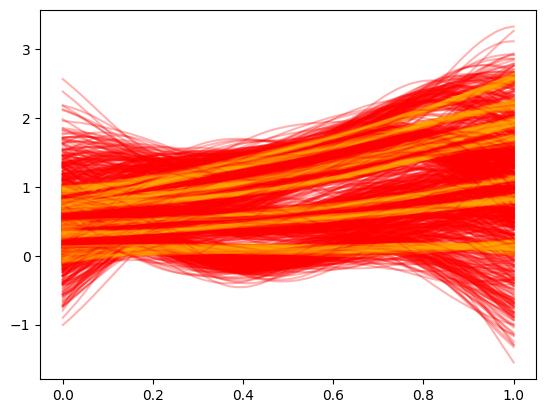

In [15]:
for l in range(100):
    for k in range(len(traj_latent[0][0])):
        plt.plot(t[k], traj_latent[l][1][k], color='red', label='Inferred Latent Derivative', alpha=0.3)
        plt.plot(t[k], traj_latent[l][0][k], color='orange', label='Inferred Latent Trajectory', alpha=0.3)
        # plt.plot(t[k], traj[k], color='green', label='True Trajectory')
        # plt.plot(t[k], traj_noisy[k], color='blue', label='Noisy Observations')

In [16]:
def compute_conditional_posterior(x, y, traj_latent, kernel, eta=1e-6):
    '''
    Compute posterior conditioned on latent trajectories z according to z'(t) = f(z(t)) + noise, where f is a function of the latent trajectory z(t). The posterior is computed using the Gaussian process framework, where the latent trajectories are treated as observations and the function f is modeled as a Gaussian process with a specified kernel. The conditional posterior mean and covariance are computed based on the observed latent trajectories and the specified kernel.
    Args:
        x: The input points at which to compute the posterior mean and covariance.
        y: The output points at which to compute the posterior mean and covariance.
        traj_latent: A list of latent trajectories, where each trajectory is a list of arrays representing the latent states at different time points.
        kernel: A function that computes the kernel (covariance) between two sets of points.
        eta: The variance of the process noise in the latent dynamics model. This parameter controls the amount of uncertainty in the latent dynamics and can be adjusted based on the specific application or data characteristics.
    Returns:
        mean: The posterior mean at the input points x, conditioned on the latent trajectories.
        covar: The posterior covariance at the input points x, conditioned on the latent trajectories.
    '''

    means = []
    covars = []
    for k in range(len(traj_latent)):
        z_k = traj_latent[k][0]
        zprime_k = traj_latent[k][1]
        z_k = np.concatenate(z_k, axis=0).reshape(-1, 1)
        zprime_k = np.concatenate(zprime_k, axis=0).reshape(-1, 1)
        K_mat = kernel(z_k, z_k)
        K_mat += eta * np.eye(K_mat.shape[0])  # Add noise variance
        K_x = kernel(x, z_k)
        K_y = kernel(y, z_k)
        mean_k = K_x @ np.linalg.solve(K_mat, zprime_k)
        covar_k = kernel(x, y) - K_x @ np.linalg.solve(K_mat, K_y.T)
        means.append(mean_k)
        covars.append(covar_k)
    return means, covars


In [17]:
import scipy as sp
def sample_posterior(x, traj_latent, kernel, eta=1e-6, num_samples=1):
    '''
    Sample from the approximate posterior distribution of the vector field f(x) conditioned on the data.  This
    distribution is a Gaussian mixture, where each component corresponds to a different latent trajectory.
    Sampling is done in the standard way for Gaussian mixture models: first, a component is selected according 
    to the mixture weights (which are uniform in this case), and then a sample is drawn from the corresponding 
    Gaussian distribution.
    Args:
        x: The input points at which to sample from the posterior distribution.  (n_pts, )
        traj_latent: A list of latent trajectories, where each trajectory is a list of arrays representing the latent states at different time points.
        kernel: The kernel function used in the Gaussian process.
        eta: The variance of the process noise in the latent dynamics model. This parameter controls the amount of uncertainty in the latent dynamics and can be adjusted based on the specific application or data characteristics.
        num_samples: The number of samples to draw from the posterior distribution.
    Returns:
        mean_samples: The mean of the samples drawn from the posterior distribution.  (n_pts, )
        std_samples: The standard deviation of the samples drawn from the posterior distribution.  (n_pts, )
        samples: The raw samples drawn from the posterior distribution.  (num_samples, n_pts)
    '''
    print('Computing conditional posteriors...')
    means, covars = compute_conditional_posterior(x, x, traj_latent, kernel, eta)
    samples = []
    print('Sampling from Gaussian mixture...')
    for k in range(num_samples):
        if k % 1000 == 0:
            print(f'Sampling {k}/{num_samples}...')
        idx = np.random.randint(len(means), size=1)
        means_k = means[idx[0]]
        covars_k = covars[idx[0]]
        samples_k = np.random.multivariate_normal(means_k.flatten(), covars_k)
        samples.append(samples_k)
    # samples = samples_k.reshape(num_samples, x.shape[0])
    # samples = np.stack(samples, axis=0)
    mean_samples = np.mean(samples, axis=0)
    std_samples = np.std(samples, axis=0)
    return mean_samples, std_samples, samples

In [18]:
# mu2 = lambda x: compute_posterior_mean(x, t, traj_noisy, traj_noisy, y_var, kernel, x0 = x0)
# covar2 = lambda x, y: compute_posterior_covar(x, y, t, traj_noisy, traj_noisy, y_var, kernel)

In [42]:
traj_concat = np.concatenate(traj_noisy, axis=0)
low_x = np.min(traj_concat)
high_x = np.max(traj_concat)
# low_x = 0.2
# high_x = 1.85
xstar = np.linspace(low_x, high_x, 100)
f_xstar = f_1(xstar[:, None])
gmm_means = []
gmm_stds = []
kernel = lambda x, y: kernels.gaussian_kernel(x, y, bw=bw)
mu_xstar, err_xstar, gmm_samples = sample_posterior(xstar[:, None], traj_latent, kernel,eta=3.5*1e-1, num_samples=5000)

Computing conditional posteriors...
Sampling from Gaussian mixture...
Sampling 0/5000...


/tmp/ipykernel_86931/2641267545.py:30: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_k = np.random.multivariate_normal(means_k.flatten(), covars_k)


Sampling 1000/5000...
Sampling 2000/5000...
Sampling 3000/5000...
Sampling 4000/5000...


Number of hits: 93/100 (93.00%)


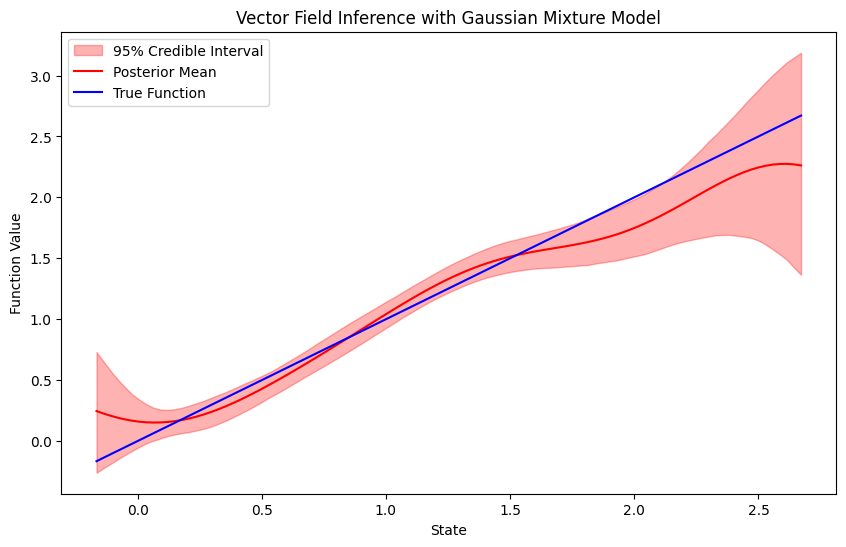

In [43]:
gmm_samples = np.stack(gmm_samples, axis=0)
low = np.zeros(gmm_samples.shape[1])
high = np.zeros(gmm_samples.shape[1])
num_hit = 0
for k in range(gmm_samples.shape[1]):
     low[k] = np.quantile(gmm_samples[:, k], 0.025, axis=0)
     high[k] = np.quantile(gmm_samples[:, k], 0.975, axis=0)
     if f_xstar[k] >= low[k] and f_xstar[k] <= high[k]:
         num_hit += 1
print(f"Number of hits: {num_hit}/{gmm_samples.shape[1]} ({num_hit/gmm_samples.shape[1]*100:.2f}%)")
plt.figure(figsize=(10, 6))
plt.fill_between(xstar, low, high, color='red', alpha=0.3, label='95% Credible Interval')
plt.plot(xstar, mu_xstar, color='red', label='Posterior Mean')
plt.plot(xstar, f_xstar, color='blue', label='True Function')
plt.xlabel('State')
plt.ylabel('Function Value')
plt.title('Vector Field Inference with Gaussian Mixture Model')
plt.legend()
plt.show()

(array([13.,  6., 17., 19.,  6.,  5.,  6.,  5.,  7., 16.]),
 array([-2.09812151, -1.72424996, -1.35037841, -0.97650686, -0.60263531,
        -0.22876376,  0.14510778,  0.51897933,  0.89285088,  1.26672243,
         1.64059398]),
 <BarContainer object of 10 artists>)

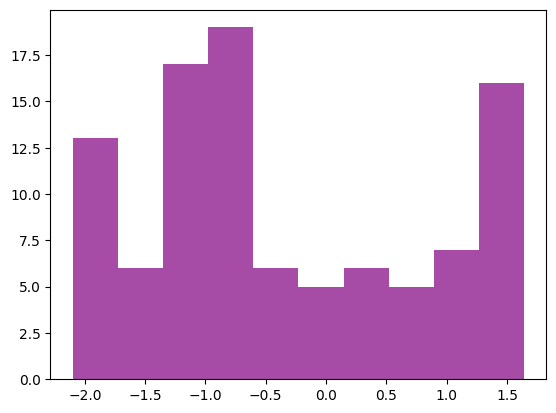

In [44]:
z_scores = (mu_xstar - f_xstar.flatten()) / err_xstar
plt.figure()
plt.hist(z_scores, bins=10, color='purple', alpha=0.7)

In [45]:
print(np.mean(z_scores), np.std(z_scores))

-0.36854857207227715 1.1715186427545423
